# ECMT6003 - Tutorial 8 - VAR Models
In this example, we revisit the seminal work of Kilian (2009). This will
provide a preview of the next lecture. Download the dataset named `Kilian2009old.dta`. In
the data, oil indicates the % change in global oil production and output is the measure of
real economic activities. The variable price denotes the logged real crude oil price.

In [1]:
%reset -f

In [2]:
import pandas            as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn           as sns
import numpy             as np
import statsmodels.api   as sm

from statsmodels.tsa.api                 import VAR
from statsmodels.tsa.stattools           import adfuller
from statsmodels.tsa.vector_ar.var_model import VARResults
from statsmodels.tsa.ardl                import ARDL

In [3]:
pd.plotting.register_matplotlib_converters()
sns.mpl.rc('figure',figsize=(16, 6))
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### Load data

In [4]:
df = pd.read_stata("Kilian2009old.dta")

In [5]:
df.head()

,oil,output,price,time
0,11.88,36.06,-48.00,1973-02-01
1,1.42,41.53,-48.29,1973-03-01
2,1.18,43.99,-47.08,1973-04-01
3,27.46,48.11,-43.86,1973-05-01
4,-13.11,52.03,-41.57,1973-06-01


### Set Time Index

In [6]:
df.index = pd.date_range(start='1973-02', periods=419, freq='MS')
df.drop(['time'], axis=1, inplace=True)

In [7]:
df

,oil,output,price
1973-02-01,11.88,36.06,-48.00
1973-03-01,1.42,41.53,-48.29
1973-04-01,1.18,43.99,-47.08
1973-05-01,27.46,48.11,-43.86
1973-06-01,-13.11,52.03,-41.57
...,...,...,...
2007-08-01,-11.46,47.05,60.21
2007-09-01,14.14,50.87,65.46
2007-10-01,10.10,56.81,73.68
2007-11-01,-3.04,57.27,81.21


### Lets check the stationarity quickly

In [8]:
df1 = pd.DataFrame()
df2 = pd.DataFrame()
df3 = pd.DataFrame()

df1['data'] = df['oil']
df2['data'] = df['output']
df3['data'] = df['price']

In [9]:
def plot_rolling(df,name):
    
    df['z_data'] = (df['data'] - df.data.rolling(window=4).mean()) / df.data.rolling(window=4).std()
    df['zp_data'] = df['z_data'] - df['z_data'].shift(1)
    df['zs_data'] = df['z_data'] - df['z_data'].shift(4)
    
    fig, ax = plt.subplots(4,figsize=(12, 9))
    ax[0].scatter(df.index, df.data, color='c', label=name)
    ax[0].plot(df.data.rolling(window=4).mean(), color='b', label="moving avergae");
    ax[0].plot(df.data.rolling(window=4).std(), color='r', label="moving std");
    ax[0].legend()

    ax[1].scatter(df.index, df.z_data, color='c', label="de-trended "+name)
    ax[1].plot(df.z_data.rolling(window=4).mean(), color='b', label="moving aveage");
    ax[1].plot(df.z_data.rolling(window=4).std(), color='r', label="moving std");
    ax[1].legend()

    ax[2].scatter(df.index, df.zp_data, color='c', label="1 lag differenced de-trended "+name)
    ax[2].plot(df.zp_data.rolling(window=4).mean(), color='b', label="moving average");
    ax[2].plot(df.zp_data.rolling(window=4).std(), color='r', label="moving std");
    ax[2].legend()
    
    ax[3].scatter(df.index, df.zs_data, color='c', label="seasonal differenced de-trended "+name)
    ax[3].plot(df.zs_data.rolling(window=4).mean(), color='b', label="moving average");
    ax[3].plot(df.zs_data.rolling(window=4).std(), color='r', label="moving std");
    ax[3].legend()

    plt.tight_layout()
    fig.autofmt_xdate()
    

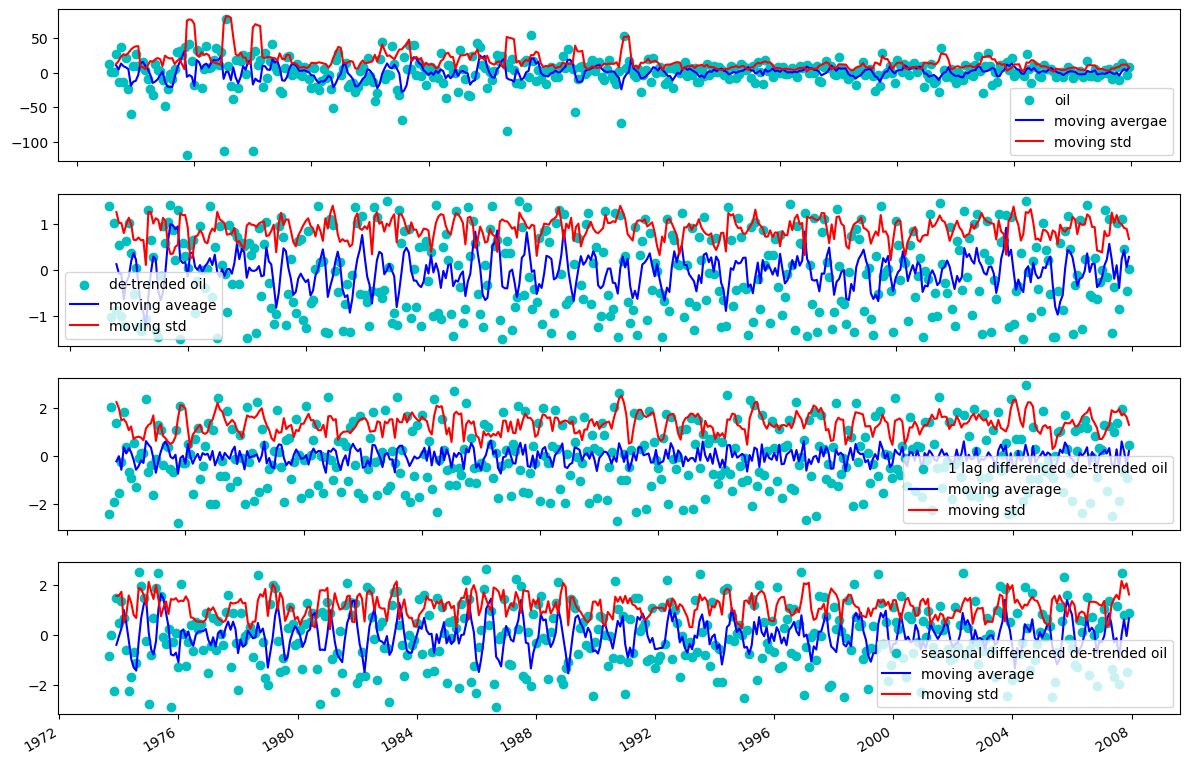

In [10]:
plot_rolling(df1,'oil')

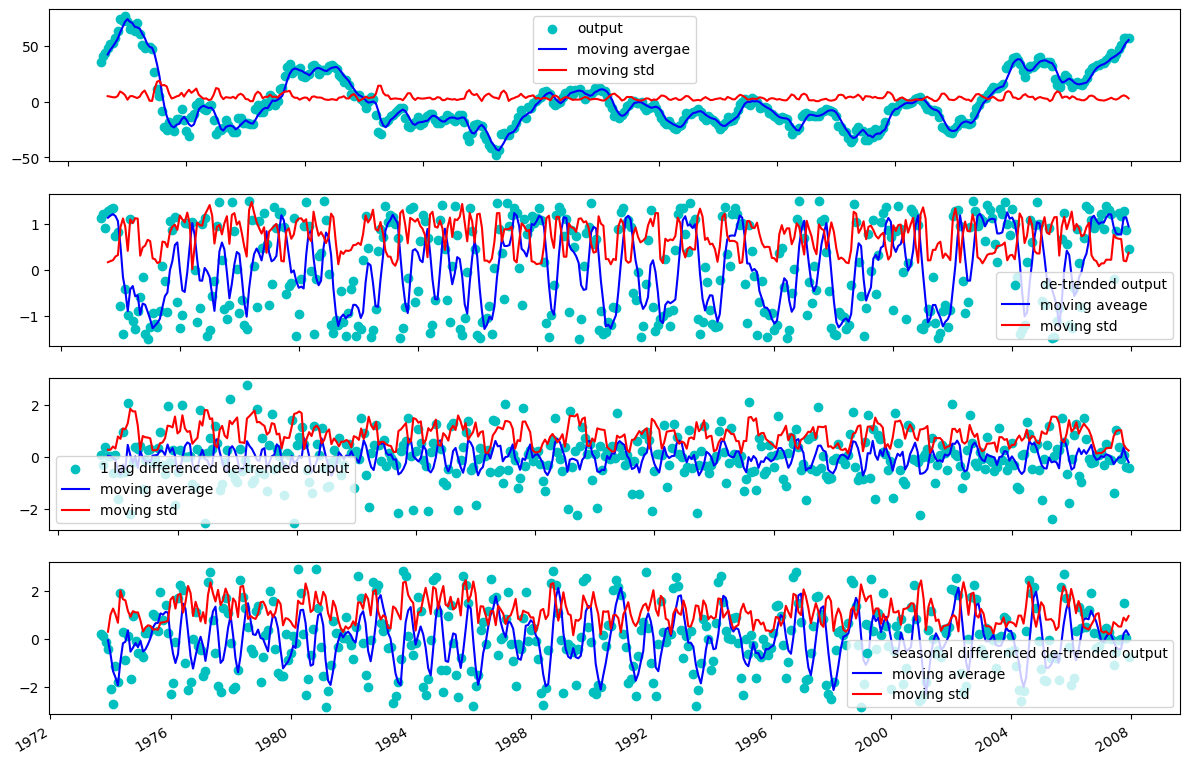

In [11]:
plot_rolling(df2,'output')

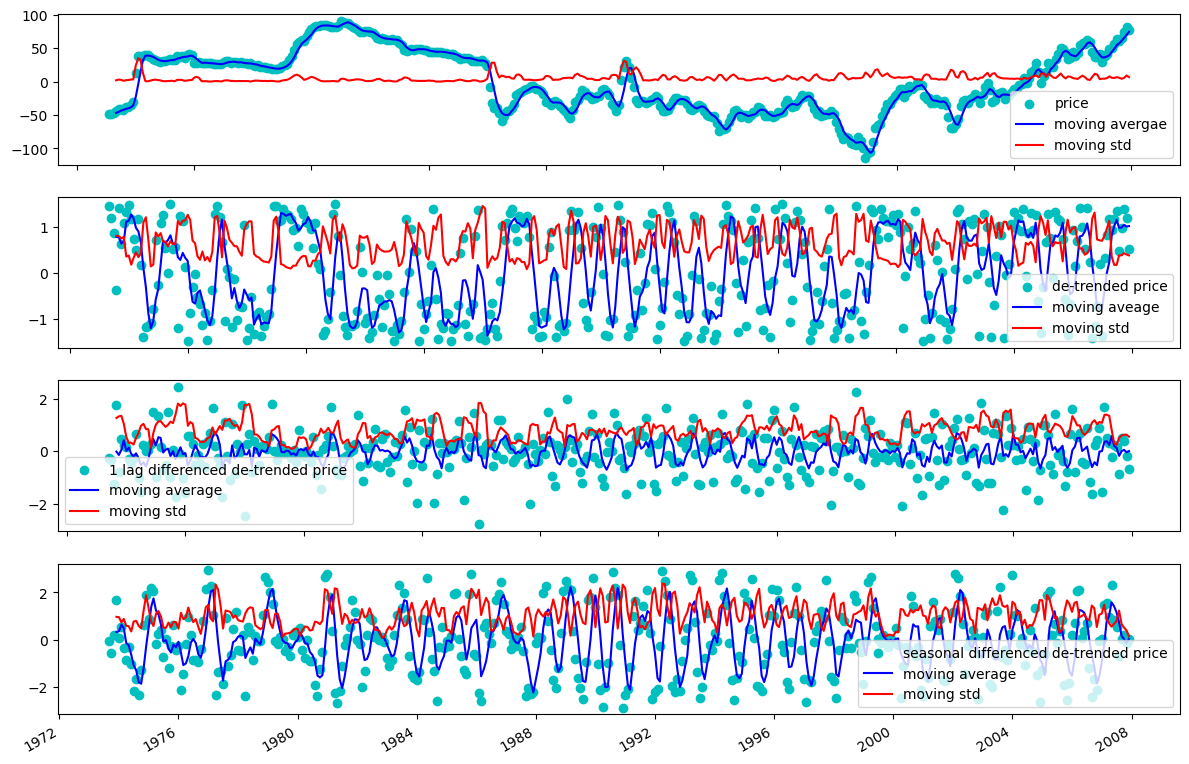

In [12]:
plot_rolling(df3,'price')

### Lets do some adf tests quickly

In [13]:
def adf_test(df,name):
    
    print("-----------------------------------------")
    print("for variable " + name)
    print("-----------------------------------------")
    
    dftest = adfuller(df.data.dropna(), autolag='BIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

    print("\n > Is the de-trended data stationary ?")
    dftest = adfuller(df.z_data.dropna(), autolag='AIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

    print("\n > Is the 1-lag differenced de-trended data stationary ?")
    dftest = adfuller(df.zp_data.dropna(), autolag='AIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))
    
    print("\n > Is the seasonal differenced de-trended data stationary ?")
    dftest = adfuller(df.zs_data.dropna(), autolag='AIC')
    print("Test statistic = {:.3f}".format(dftest[0]))
    print("P-value = {:.3f}".format(dftest[1]))
    print("Critical values :")
    for k, v in dftest[4].items():
        print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

In [14]:
adf_test(df1,'oil')

-----------------------------------------
for variable oil
-----------------------------------------
Test statistic = -22.347
P-value = 0.000
Critical values :
	1%: -3.4460914174990296 - The data is  stationary with 99% confidence
	5%: -2.868479374038333 - The data is  stationary with 95% confidence
	10%: -2.570466459559076 - The data is  stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -11.883
P-value = 0.000
Critical values :
	1%: -3.4464005219454155 - The data is  stationary with 99% confidence
	5%: -2.868615280538588 - The data is  stationary with 95% confidence
	10%: -2.570538905413444 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -10.368
P-value = 0.000
Critical values :
	1%: -3.446845912589748 - The data is  stationary with 99% confidence
	5%: -2.8688110853002007 - The data is  stationary with 95% confidence
	10%: -2.5706432834592747 - The data is  stationary with 90

In [15]:
adf_test(df2,'output') 

-----------------------------------------
for variable output
-----------------------------------------
Test statistic = -2.567
P-value = 0.100
Critical values :
	1%: -3.446129402876608 - The data is not stationary with 99% confidence
	5%: -2.8684960761128346 - The data is not stationary with 95% confidence
	10%: -2.570475362616382 - The data is not stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -5.960
P-value = 0.000
Critical values :
	1%: -3.4467631030732506 - The data is  stationary with 99% confidence
	5%: -2.868774682311516 - The data is  stationary with 95% confidence
	10%: -2.570623877774392 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -7.484
P-value = 0.000
Critical values :
	1%: -3.446845912589748 - The data is  stationary with 99% confidence
	5%: -2.8688110853002007 - The data is  stationary with 95% confidence
	10%: -2.5706432834592747 - The data is  stationar

In [16]:
adf_test(df3,'price')

-----------------------------------------
for variable price
-----------------------------------------
Test statistic = -2.269
P-value = 0.182
Critical values :
	1%: -3.446129402876608 - The data is not stationary with 99% confidence
	5%: -2.8684960761128346 - The data is not stationary with 95% confidence
	10%: -2.570475362616382 - The data is not stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -5.607
P-value = 0.000
Critical values :
	1%: -3.4466811208382437 - The data is  stationary with 99% confidence
	5%: -2.8687386420385494 - The data is  stationary with 95% confidence
	10%: -2.5706046655665635 - The data is  stationary with 90% confidence

 > Is the 1-lag differenced de-trended data stationary ?
Test statistic = -7.685
P-value = 0.000
Critical values :
	1%: -3.4469717056192213 - The data is  stationary with 99% confidence
	5%: -2.868866381945153 - The data is  stationary with 95% confidence
	10%: -2.570672761197837 - The data is  stationar

(a). Let $Y_t = (oil, \Delta output, \Delta price)′$ and obtain the multivariate AIC and BIC criteria. What
is the optimal lag?

### We can see that oil is stationary, but price and output are non-stationary

### Thus we have to difference the non-stationary series

In [17]:
df['price']  = df['price'].diff(1)
df['output'] = df['output'].diff(1)

df = df.dropna()

df.head()

,oil,output,price
1973-03-01,1.42,5.46,-0.29
1973-04-01,1.18,2.46,1.20
1973-05-01,27.46,4.11,3.22
1973-06-01,-13.11,3.93,2.29
1973-07-01,36.26,0.91,0.58


In [18]:
df = df.rename(columns={"output" : "D1_output"})
df = df.rename(columns={"price"  : "D1_price"})

df.head()

,oil,D1_output,D1_price
1973-03-01,1.42,5.46,-0.29
1973-04-01,1.18,2.46,1.20
1973-05-01,27.46,4.11,3.22
1973-06-01,-13.11,3.93,2.29
1973-07-01,36.26,0.91,0.58


### We will use BIC when selecting the order of var

### The following function, 

#### training the VAR model
#### report the training result
#### plot the input processes
#### plot the acf
#### plot the irf
#### plot cumulative effects
#### do Granger tests
#### compute Ljung-Box test

#### You only need to input the dataframe "df" and set the lag number "i"

In [19]:
def var_est(df,i):
    
    print("---------------------------------------------")
    print("VAR result for max lag = " + str(i))
    print("---------------------------------------------")
    
    model  = VAR(df)
    result = model.fit(i, trend='c')
    
    print(result.summary())
    
    print("---------------------------------------------")
    print("Plotting input time series")
    print("---------------------------------------------")
    
    result.plot()
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting time series autocorrelation function")
    print("---------------------------------------------")
          
    result.plot_acorr()
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting IRF")
    print("---------------------------------------------")
    
    irf = result.irf(10)
    irf.plot(orth=False)
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting cumulative effects")
    print("---------------------------------------------")
    
    irf.plot_cum_effects(orth=False)
    plt.show()
    
    print("---------------------------------------------")
    print("Granger test")
    print("---------------------------------------------")
    
    test_result1 = result.test_causality('oil', ['D1_output', 'D1_price'], kind='f')
    print(test_result1.summary())
    
    test_result2 = result.test_causality('D1_price', ['oil', 'D1_output'], kind='f')
    print(test_result2.summary())
    
    test_result3 = result.test_causality('D1_output', ['D1_price', 'oil'], kind='f')
    print(test_result3.summary())
    
    print("---------------------------------------------")
    print("Ljung-Box test for VAR")
    print("---------------------------------------------")
    test_result4 = result.test_whiteness()
    print(test_result4.summary())

---------------------------------------------
VAR result for max lag = 1
---------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:07:37
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    12.9267
Nobs:                     417.000    HQIC:                   12.8565
Log likelihood:          -4434.11    FPE:                    366084.
AIC:                      12.8106    Det(Omega_mle):         355748.
--------------------------------------------------------------------
Results for equation oil
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.927990         1.006497            0.922           0.357
L1.oil              -0.0960

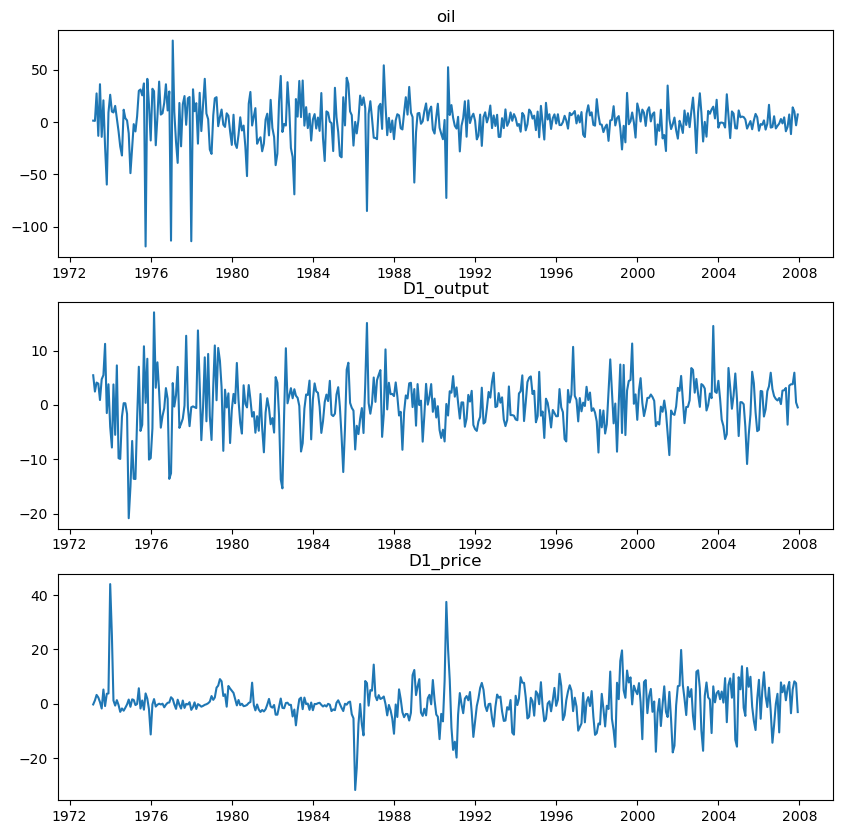

---------------------------------------------
Plotting time series autocorrelation function
---------------------------------------------


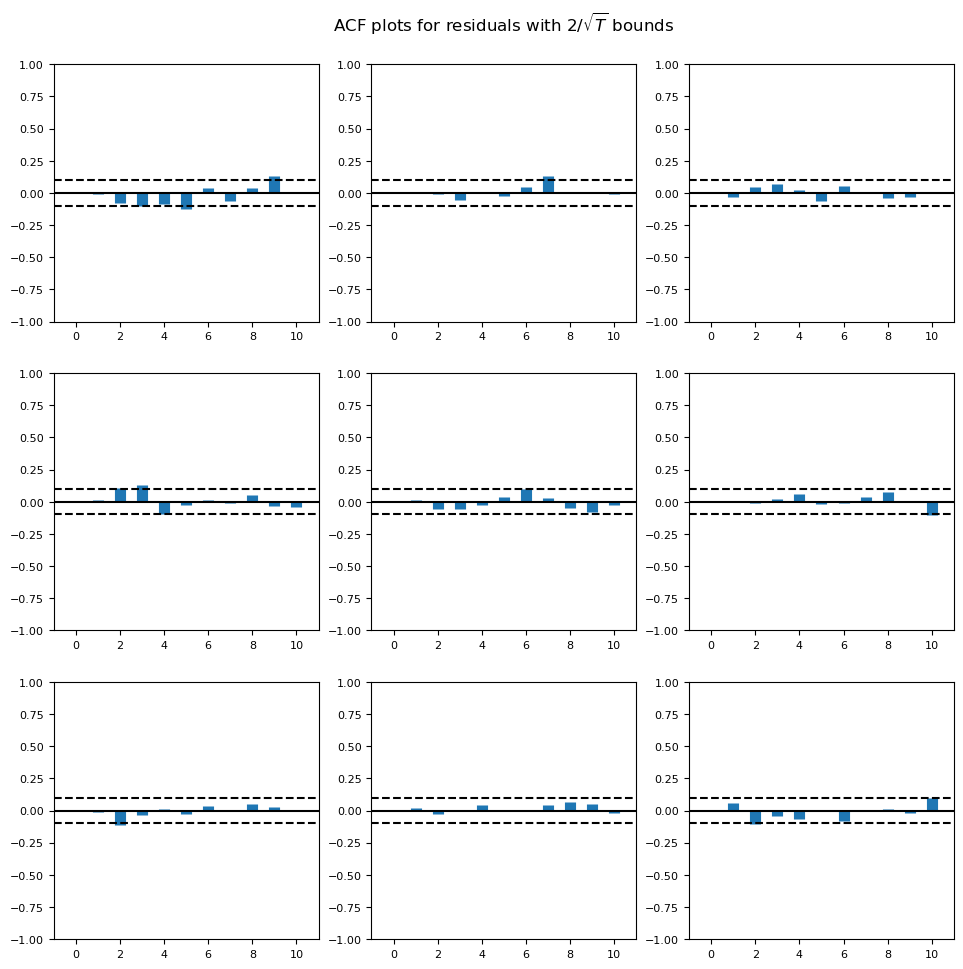

---------------------------------------------
Plotting IRF
---------------------------------------------


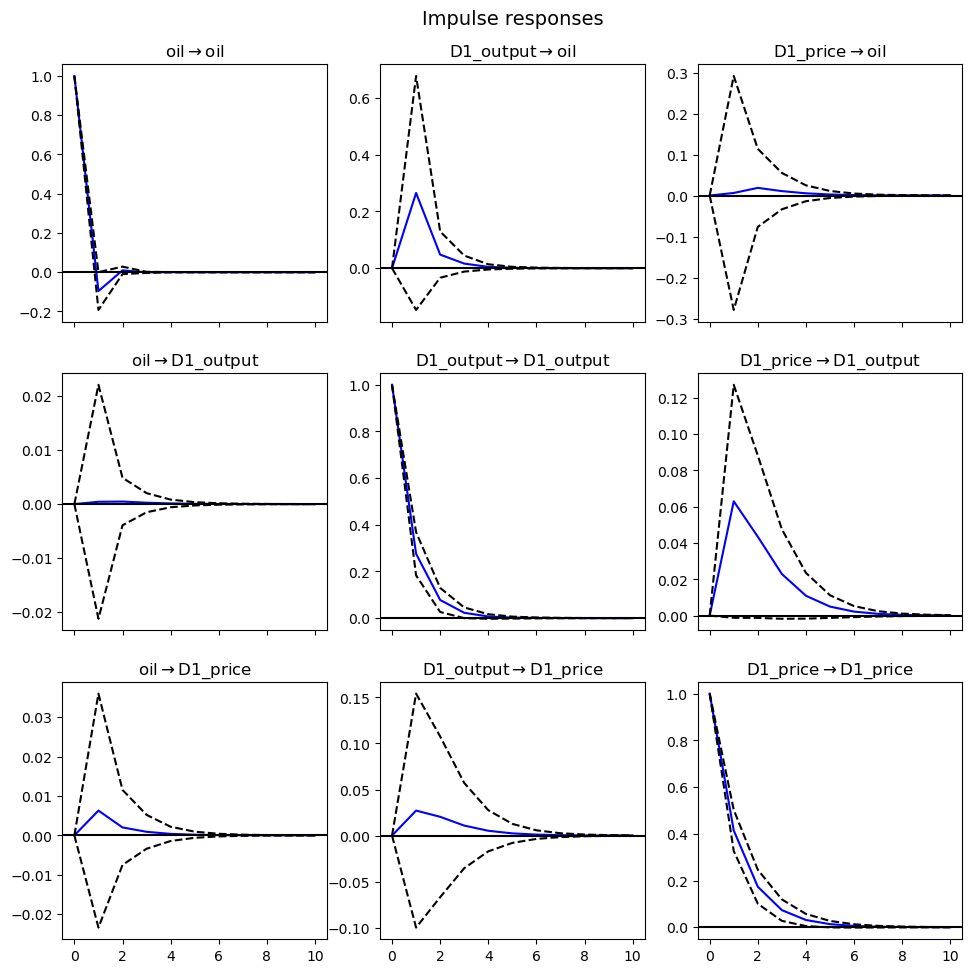

---------------------------------------------
Plotting cumulative effects
---------------------------------------------


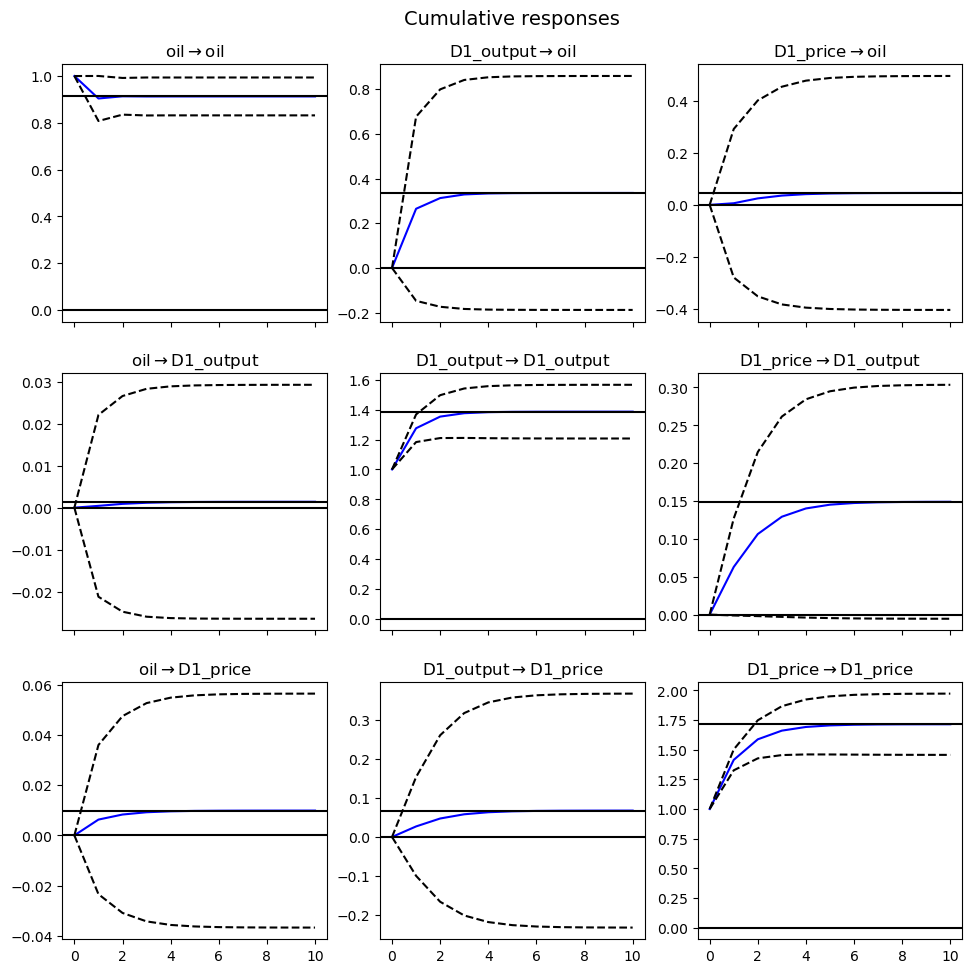

---------------------------------------------
Granger test
---------------------------------------------
Granger causality F-test. H_0: ['D1_output', 'D1_price'] do not Granger-cause oil. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.8049          3.003   0.447 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['oil', 'D1_output'] do not Granger-cause D1_price. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1896          3.003   0.827 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['D1_price', 'oil'] do not Granger-cause D1_output. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-------------------------------------------

In [20]:
var_est(df,1)

### Now let's write a function to select the lag number and do all the things above.

In [21]:
def var_est_BIC(df,i):
    
    print("---------------------------------------------")
    print("VAR result for lag = " + str(i))
    print("---------------------------------------------")
    
    model  = VAR(df)
    result = model.fit(maxlags=i, ic='bic', trend='c',verbose=True)
    
    print(result.summary())
    
    print("---------------------------------------------")
    print("Plotting input time series")
    print("---------------------------------------------")
    
    result.plot()
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting time series autocorrelation function")
    print("---------------------------------------------")
          
    result.plot_acorr()
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting IRF")
    print("---------------------------------------------")
    
    irf = result.irf(10)
    irf.plot(orth=False)
    plt.show()
    
    print("---------------------------------------------")
    print("Plotting cumulative effects")
    print("---------------------------------------------")
    
    irf.plot_cum_effects(orth=False)
    plt.show()
    
    print("---------------------------------------------")
    print("Granger test")
    print("---------------------------------------------")
    
    test_result1 = result.test_causality('oil', ['D1_output', 'D1_price'], kind='f')
    print(test_result1.summary())
    
    test_result2 = result.test_causality('D1_price', ['oil', 'D1_output'], kind='f')
    print(test_result2.summary())
    
    test_result3 = result.test_causality('D1_output', ['D1_price', 'oil'], kind='f')
    print(test_result3.summary())
    
    print("---------------------------------------------")
    print("Ljung-Box test for VAR")
    print("---------------------------------------------")
    test_result4 = result.test_whiteness()
    print(test_result4.summary())

In [22]:
### let's do the selection and training on "df" with max lag number = 5
### apparently, BIC choose p = 1

---------------------------------------------
VAR result for lag = 5
---------------------------------------------
<statsmodels.tsa.vector_ar.var_model.LagOrderResults object. Selected orders are: AIC -> 3, BIC -> 1, FPE -> 3, HQIC ->  1>
Using 1 based on bic criterion
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:07:40
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    12.9267
Nobs:                     417.000    HQIC:                   12.8565
Log likelihood:          -4434.11    FPE:                    366084.
AIC:                      12.8106    Det(Omega_mle):         355748.
--------------------------------------------------------------------
Results for equation oil
                  coefficient       std. error           t-stat            prob
------------------------------------

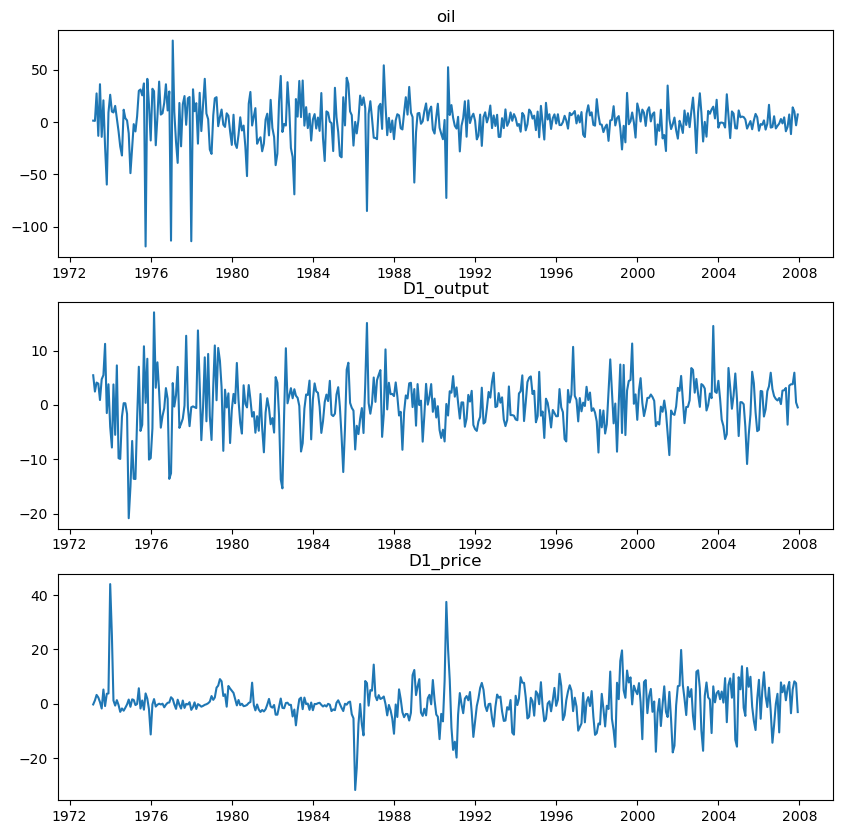

---------------------------------------------
Plotting time series autocorrelation function
---------------------------------------------


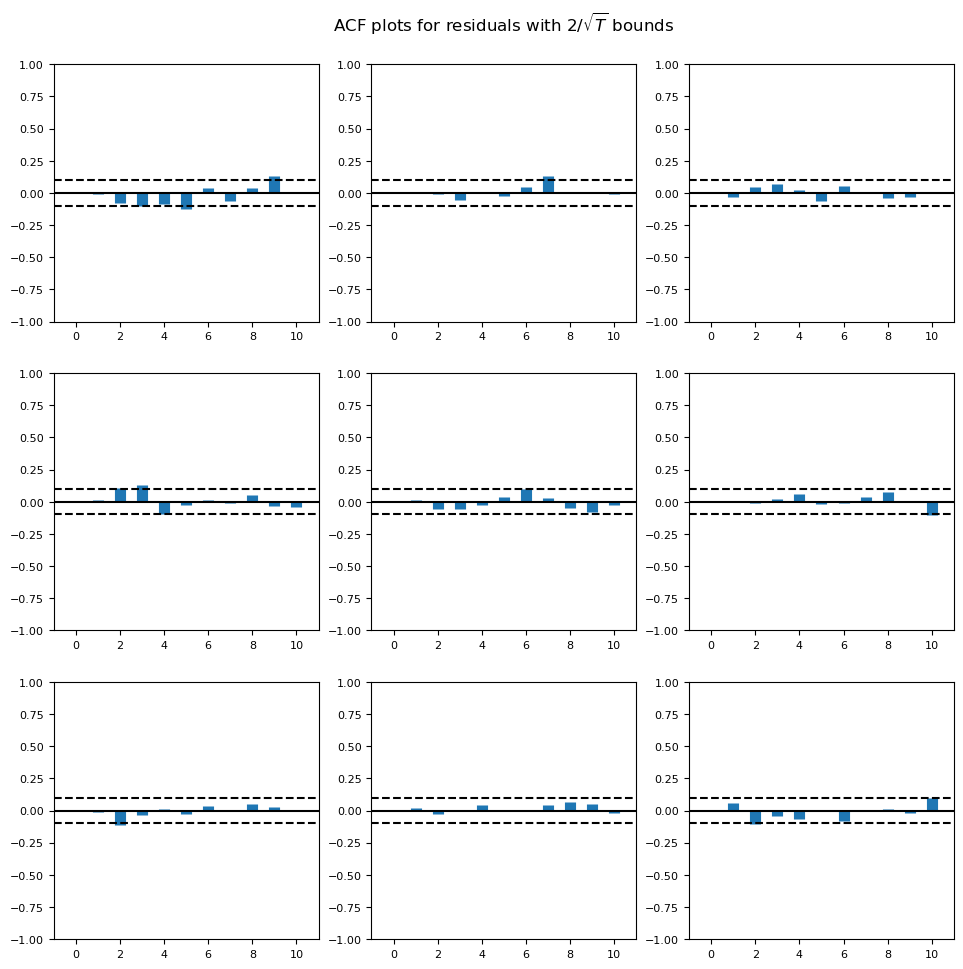

---------------------------------------------
Plotting IRF
---------------------------------------------


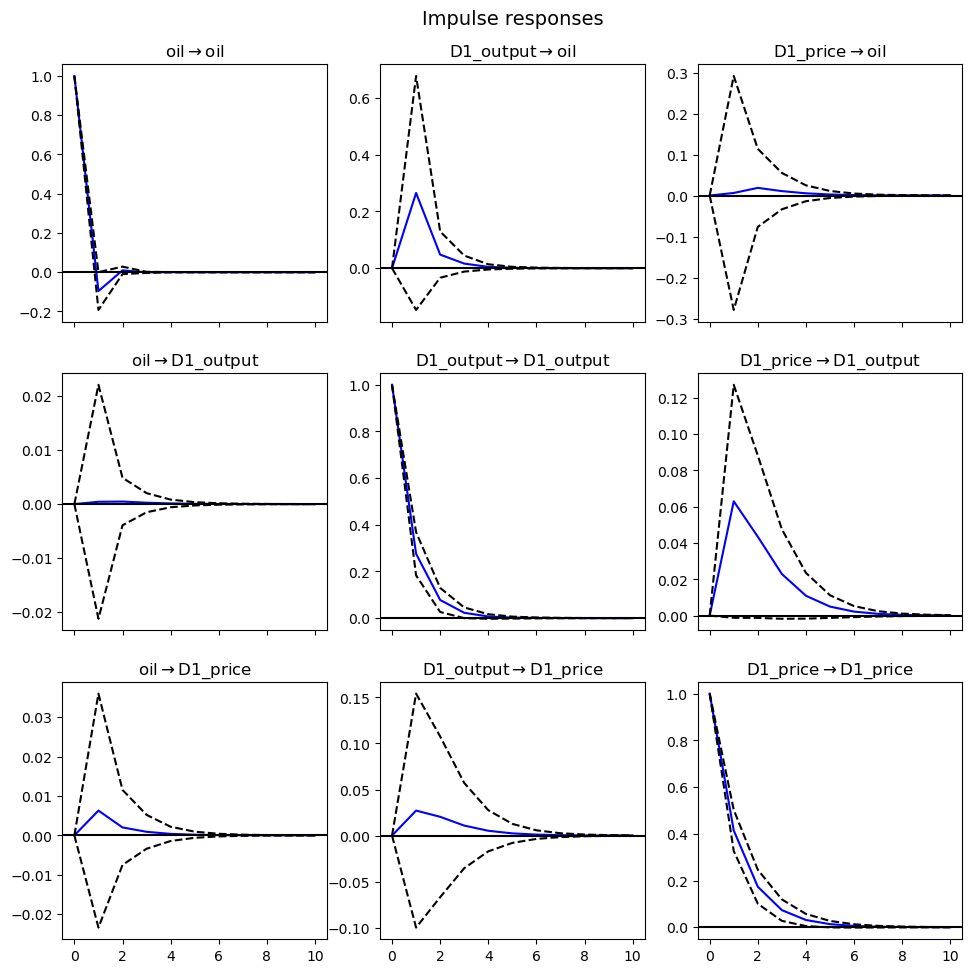

---------------------------------------------
Plotting cumulative effects
---------------------------------------------


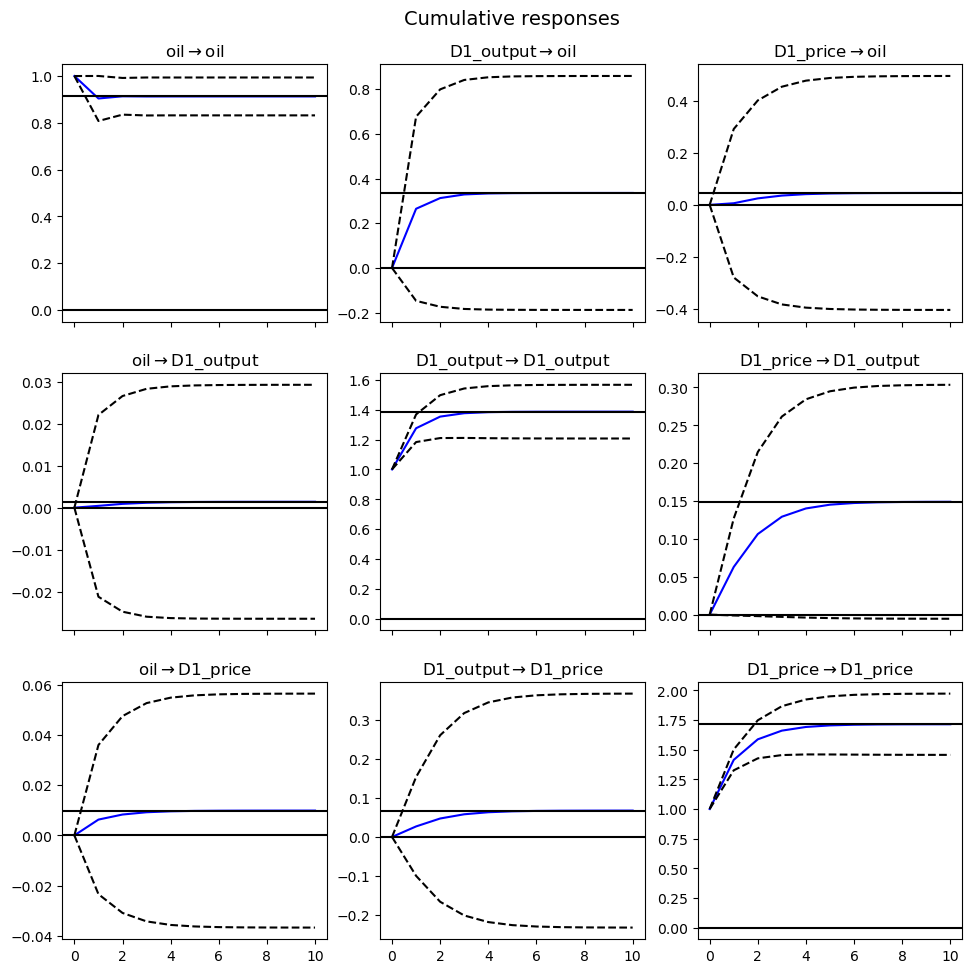

---------------------------------------------
Granger test
---------------------------------------------
Granger causality F-test. H_0: ['D1_output', 'D1_price'] do not Granger-cause oil. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.8049          3.003   0.447 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['oil', 'D1_output'] do not Granger-cause D1_price. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1896          3.003   0.827 (2, 1239)
-----------------------------------------------
Granger causality F-test. H_0: ['D1_price', 'oil'] do not Granger-cause D1_output. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-------------------------------------------

In [23]:
var_est_BIC(df,5)

### now let's focus on the VAR result (selected by BIC)
(b) Using the lag selected in (a), estimate the VAR coefficients and test the stationarity.

In [24]:
model  = VAR(df)
result = model.fit(1, trend='c')

In [25]:
result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 20, Aug, 2026
Time:                     22:07:43
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                    12.9267
Nobs:                     417.000    HQIC:                   12.8565
Log likelihood:          -4434.11    FPE:                    366084.
AIC:                      12.8106    Det(Omega_mle):         355748.
--------------------------------------------------------------------
Results for equation oil
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const                0.927990         1.006497            0.922           0.357
L1.oil              -0.096006         0.049105           -1.955           0.051
L1.D1_output         0.264808         0.210096            1.260   

(d) Test whether the error term is serially correlated. Interpret the results.

Now lets check the eigenvalues of the companion coefficients matrix for the above VAR model

In [26]:
result.is_stable(verbose =1)

Eigenvalues of VAR(1) rep
0.09583751397098023
0.42710897123438263
0.2629096623796193


True

Note that all eigen vlaues are real and less than 1 in modulus. This all are within the unit circle and hence are stationary

Lets also check the residuals of the portmanteau / Ljung-Box test

The p value rejects $H_0$ such that there is no autocorrelation at the lag order $p=1$

This means the model is to simple and doesn't extract all the useful patterns from the data 

In [27]:
test_result = result.test_whiteness(nlags = 10, signif = 0.05)
print(test_result.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 10 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         112.9          103.0   0.011 81
----------------------------------------


(e). From the above VAR model, obtain the first 4 coefficients of MA representation. Inter-
pret the results.

Now lets compute the coefficient matrices of the MA representation

In [28]:
result.ma_rep()

array([[[ 1.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00]],

       [[-9.60061720e-02,  2.64808179e-01,  6.30267242e-03],
        [ 4.32384382e-04,  2.75774937e-01,  6.29438708e-02],
        [ 6.28522007e-03,  2.71159618e-02,  4.14412354e-01]],

       [[ 9.37129767e-03,  4.77751424e-02,  1.86748617e-02],
        [ 4.73345287e-04,  7.78730986e-02,  4.34457849e-02],
        [ 2.01297745e-03,  2.03794699e-02,  1.73483997e-01]],

       [[-7.61669576e-04,  1.61631700e-02,  1.08053100e-02],
        [ 2.61293362e-04,  2.27788688e-02,  2.29090876e-02],
        [ 9.05938603e-04,  1.08573854e-02,  7.31893614e-02]],

       [[ 1.48027434e-04,  4.54869724e-03,  5.49042589e-03],
        [ 1.28752109e-04,  6.97223569e-03,  1.09292460e-02],
        [ 3.77730109e-04,  5.21869465e-03,  3.10196912e-02]],

       [[ 2.22637733e-05,  1.44249375e-03,  2.56254590e-03],
        [ 5.93

(c). Let price be the dependent variable and estimate the AR-DL model. You can use the
lag selected in (a). Compare the estimation results with those in (b).

Now we compute the ARDL of each VAR Equation $(p=2)$.

In [29]:
ardl_model = ARDL(endog = df['D1_price'], 
                  lags = 2, 
                  exog = df[["oil", "D1_output"]], 
                  order = 2,
                 #trend = "ct",
                 #seasonal = True
                 )
ardl_result = ardl_model.fit()

In [30]:
print(ardl_result.summary())

                              ARDL Model Results                              
Dep. Variable:               D1_price   No. Observations:                  418
Model:                  ARDL(2, 2, 2)   Log Likelihood               -1349.115
Method:               Conditional MLE   S.D. of innovations              6.197
Date:                Thu, 20 Aug 2026   AIC                           2718.230
Time:                        22:07:43   BIC                           2758.537
Sample:                    05-01-1973   HQIC                          2734.167
                         - 12-01-2007                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.2313      0.309      0.750      0.454      -0.375       0.838
D1_price.L1      0.4673      0.049      9.532      0.000       0.371       0.564
D1_price.L2     -0.1353      0.049     -2.75

### Lets use OLS as a comparison

In [31]:
df['L1_oil'] = df['oil'].shift(1)
df['L2_oil'] = df['oil'].shift(2)

df['L1_output'] = df['D1_output'].shift(1)
df['L2_output'] = df['D1_output'].shift(2)

df['L1_price'] = df['D1_price'].shift(1)
df['L2_price'] = df['D1_price'].shift(2)

#df = df.drop(['D1_output','oil'], axis=1)

df

,oil,D1_output,D1_price,L1_oil,L2_oil,L1_output,L2_output,L1_price,L2_price
1973-03-01,1.42,5.46,-0.29,NaN,NaN,NaN,NaN,NaN,NaN
1973-04-01,1.18,2.46,1.20,1.42,NaN,5.46,NaN,-0.29,NaN
1973-05-01,27.46,4.11,3.22,1.18,1.42,2.46,5.46,1.20,-0.29
1973-06-01,-13.11,3.93,2.29,27.46,1.18,4.11,2.46,3.22,1.20
1973-07-01,36.26,0.91,0.58,-13.11,27.46,3.93,4.11,2.29,3.22
...,...,...,...,...,...,...,...,...,...
2007-08-01,-11.46,3.80,-3.53,7.31,-4.53,3.55,-3.63,8.00,5.58
2007-09-01,14.14,3.81,5.24,-11.46,7.31,3.80,3.55,-3.53,8.00
2007-10-01,10.10,5.94,8.22,14.14,-11.46,3.81,3.80,5.24,-3.53
2007-11-01,-3.04,0.47,7.53,10.10,14.14,5.94,3.81,8.22,5.24


In [32]:
df = df.dropna()

Y = df['D1_price']
X = sm.add_constant(df.drop(['D1_price'], axis=1))

In [33]:
mod = sm.OLS(Y,X)
res = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:               D1_price   R-squared:                       0.201
Model:                            OLS   Adj. R-squared:                  0.186
Method:                 Least Squares   F-statistic:                     12.82
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           1.72e-16
Time:                        22:07:43   Log-Likelihood:                -1349.1
No. Observations:                 416   AIC:                             2716.
Df Residuals:                     407   BIC:                             2753.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2313      0.309      0.750      0.4